# Preprocesamiento final

En este notebook se aplican las decisiones de limpieza y transformación definidas a partir del análisis exploratorio realizado en el notebook anterior. El objetivo es obtener un conjunto de datos consistente y preparado para la fase de modelado predictivo del precio de venta de los inmuebles.

A partir del dataset "spanish_houses_processed.csv", se tratarán los registros correspondientes a alquiler, los valores anómalos de la variable objetivo, los valores ausentes, las variables categóricas de alta cardinalidad y las posibles inconsistencias en las variables numéricas y de superficie. También se seleccionarán y transformarán las variables necesarias para su posterior utilización en los modelos.

Las decisiones tomadas en esta fase se basan en los resultados obtenidos durante el EDA, evitando realizar transformaciones innecesarias o eliminar observaciones únicamente por presentar valores extremos cuando estos sean plausibles.

In [1192]:
import pandas as pd
import numpy as np

## 1. Preparación del dataset

In [1193]:
df = pd.read_csv("../data/processed/spanish_houses_preprocessed.csv")
print("Dimensiones del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

Dimensiones del dataset: (99816, 41)

Columnas:
['ad_description', 'ad_last_update', 'air_conditioner', 'balcony', 'bath_num', 'built_in_wardrobe', 'chimney', 'condition', 'construct_date', 'energetic_certif', 'floor', 'garage', 'garden', 'ground_size', 'heating', 'house_id', 'house_type', 'kitchen', 'lift', 'loc_city', 'loc_district', 'loc_full', 'loc_neigh', 'loc_street', 'loc_zone', 'm2_real', 'm2_useful', 'obtention_date', 'orientation', 'price', 'reduced_mobility', 'room_num', 'storage_room', 'swimming_pool', 'terrace', 'unfurnished', 'number_of_companies_prov', 'population_prov', 'companies_prov_vs_national_%', 'population_prov_vs_national_%', 'renta_media_prov']


## 2. Filtrado de registros

Se realizarán los cambios documentados en el EDA:

- Eliminar los alquileres.
- Eliminar los registros con `price = 1 €`

In [1194]:
print("Registros iniciales:", len(df))

Registros iniciales: 99816


In [1195]:
# Filtramos los registros de alquiler
is_rental = df["house_type"].str.contains("Alquiler",case=False,na=False)

print("Registros de alquiler:", is_rental.sum())
print("Registros de venta:", (~is_rental).sum())

Registros de alquiler: 2611
Registros de venta: 97205


In [1196]:
# Nos quedamos solo con las ventas
df = df.loc[~is_rental].copy()

In [1197]:
print("Registros después de eliminar alquileres:", len(df))

Registros después de eliminar alquileres: 97205


In [1198]:
# Eliminamos los 2 registros con price = 1
df = df.loc[df["price"] > 1].copy()

In [1199]:
print("Dimensiones finales tras el filtrado:", df.shape)

print(
    "Registros cuyo house_type contiene 'Alquiler':",
    df["house_type"].str.contains(
        "Alquiler",
        case=False,
        na=False
    ).sum()
)

Dimensiones finales tras el filtrado: (97203, 41)


Registros cuyo house_type contiene 'Alquiler': 0


## 3. Revisión de valores extremos 

### 3.1. Superficies

Revisamos si hay incoherencias en las variables `m2_real` y `m2_useful`.

In [1200]:
surface_vars = ["m2_real", "m2_useful"]
df[surface_vars].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,m2_real,m2_useful
count,97203.000000,51044.000000
mean,1744.382282,142.162585
std,18467.383567,758.301258
min,1.000000,1.000000
1%,40.000000,36.000000
5%,55.000000,50.000000
25%,81.000000,72.000000
50%,114.000000,94.000000
75%,250.000000,154.000000
95%,3550.900000,350.000000


In [1201]:
df.loc[
    df["m2_real"] > df["m2_real"].quantile(0.99),
    [
        "house_id",
        "house_type",
        "price",
        "m2_real",
        "m2_useful",
        "room_num",
        "bath_num",
        "loc_city"
    ]
].sort_values("m2_real", ascending=False).head(30)

,house_id,house_type,price,m2_real,m2_useful,room_num,bath_num,loc_city
89236,83534171,Casa o chalet independiente,3000000,900000,NaN,9.0,8.0,El Pedroso
31036,83962785,Casa o chalet,6000000,900000,625.0,13.0,5.0,Bunyola
32487,83317390,Finca rústica,3182000,891800,1648.0,3.0,2.0,Sencelles
32403,39083809,Casa rural,3450000,890000,1613.0,6.0,2.0,Sencelles
32350,82593599,Finca rústica,1300000,860000,75.0,NaN,NaN,Sencelles
28985,84893392,Casa o chalet,5500000,851360,600.0,3.0,2.0,Villafranca de Bonany
35526,84122424,Masía,350000,850000,355.0,6.0,2.0,Pontons
12217,30076287,Finca rústica,2900000,850000,NaN,6.0,3.0,Ferreries
31151,38908237,Casa o chalet independiente,840000,840000,780.0,9.0,7.0,Palmanyola
11843,40038497,Casa o chalet,3950000,830000,NaN,16.0,2.0,Maó/Mahon


In [1202]:
print("Casos donde m2_useful > m2_real:", (df["m2_useful"] > df["m2_real"]).sum())
print("Casos con m2_useful <= 0:", (df["m2_useful"] <= 0).sum())

Casos donde m2_useful > m2_real: 1682
Casos con m2_useful <= 0: 0


Vamos a verificar en que casos y tipos de inmueble sucede esto:

In [1203]:
df.loc[
    df["m2_useful"] > df["m2_real"],
    [
        "house_id",
        "house_type",
        "price",
        "m2_real",
        "m2_useful",
        "room_num",
        "bath_num",
        "loc_city"
    ]
].head(30)

,house_id,house_type,price,m2_real,m2_useful,room_num,bath_num,loc_city
16,83828882,Casa de pueblo,350000,90,180.0,3.0,3.0,Legutiano
62,81595851,Chalet adosado,315000,60,220.0,4.0,4.0,Zuya
78,39526241,Chalet pareado,270000,195,310.0,4.0,3.0,Zuya
85,36747997,Chalet adosado,255000,135,146.0,3.0,3.0,Zuya
98,38294021,Chalet adosado,295000,100,110.0,4.0,3.0,Arrazua-Ubarrundia
107,39893216,Chalet pareado,332000,70,229.0,4.0,4.0,Zuya
126,32016904,Chalet pareado,248000,200,318.0,4.0,4.0,Zuya
166,2106177,Chalet adosado,390000,65,250.0,4.0,4.0,Zuya
167,35511480,Chalet adosado,355000,90,130.0,3.0,3.0,Zuya
181,84411806,Chalet adosado,249000,15,159.0,3.0,3.0,Legutiano


In [1204]:
df.loc[
    df["m2_useful"] > df["m2_real"],
    "house_type"
].value_counts().head(15)

house_type
 Chalet adosado                 701
 Casa o chalet independiente    316
 Casa o chalet                  250
 Casa de pueblo                 191
 Chalet pareado                 162
 Casa rural                      20
 Finca rústica                   19
Casa rural                       12
 Caserón                          6
 Cortijo                          2
 Masía                            1
 Palacio                          1
 Castillo                         1
Name: count, dtype: int64

### Conlusión de las superficies

Las variables `m2_real` y `m2_useful` presentan distribuciones claramente asimétricas y algunos valores extremos. En `m2_real`, la mediana es de 114 $m^2$, mientras que el percentil 99 alcanza aproximadamente 25.198 $m^2$ y el máximo 900.000 $m^2$. La inspección de los valores extremos muestra que estos se concentran principalmente en fincas rústicas, casas rurales, masías o castillos, por lo que no se consideran errores y se mantienen.

`m2_useful` presenta valores más contenidos, con una mediana de 94 $m^2$ y un percentil 99 de 600 $m^2$, aunque también aparecen algunos valores extremos.

Se detectan además 1.682 registros en los que `m2_useful` es superior a `m2_real`. Aunque algunos registros parecen potencialmente inconsistentes, no se dispone de información suficiente para determinar cuál de las dos medidas es incorrecta. Por este motivo, se verificará si sigue habiendo inconsistencias también con otras variables como `room_num` y `bath_num` antes de tomar una decisión.

En consecuencia, no se eliminan registros por presentar superficies extremas y se conservan `m2_real` y `m2_useful` para su evaluación posterior durante el modelado.


### 3.2. Habitaciones y baños

In [1205]:
df[["room_num", "bath_num"]].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,room_num,bath_num
count,95973.000000,96533.000000
mean,3.264251,1.997162
std,1.523046,1.223895
min,1.000000,1.000000
1%,1.000000,1.000000
5%,1.000000,1.000000
25%,2.000000,1.000000
50%,3.000000,2.000000
75%,4.000000,2.000000
95%,6.000000,4.000000


In [1206]:
df.loc[
    (df["room_num"] > df["room_num"].quantile(0.99)) |
    (df["bath_num"] > df["bath_num"].quantile(0.99)),
    [
        "house_id",
        "house_type",
        "price",
        "m2_real",
        "m2_useful",
        "room_num",
        "bath_num",
        "loc_city"
    ]
].sort_values(
    ["room_num", "bath_num"],
    ascending=False
).head(30)

,house_id,house_type,price,m2_real,m2_useful,room_num,bath_num,loc_city
15493,83628968,Palacio,23000000,3,NaN,84.0,84.0,Valldemossa
90897,84163769,Casa o chalet independiente,1200000,3095,NaN,73.0,75.0,Espartinas
30497,39726934,Casa o chalet,4500000,39000,NaN,65.0,NaN,Manacor
86869,32433651,Caserón,4000000,7763,NaN,58.0,58.0,Ayllon
78456,30178388,Piso,3600000,1980,NaN,56.0,2.0,Roses
13382,83681116,Casa o chalet independiente,1850000,2000,NaN,36.0,20.0,Sant Josep de Sa Talaia
6206,84692493,Finca rústica,390000,60000,2750.0,35.0,15.0,Bonete
52359,37071101,Castillo,1850000,5250,NaN,34.0,4.0,Orozko
31467,84581626,Casa o chalet independiente,2800000,1458,NaN,32.0,32.0,Canyamel
98483,33660198,Piso,1500000,2170,NaN,32.0,18.0,Zamora


Viendo filas en la comprobación anterior como la del `house_id` = 83628968, vamos a eliminar las filas inconsistentes. En esta por ejemplo, m2_real es 3 $m^2$ y m2_useful es NaN. Sin embargo, hay 84 habitaciones y 84 baños. Aunque pone que se trata de un palacio, es una fila inconsistente.

In [1207]:
# Casos con muchas habitaciones para una superficie muy reducida
df[
    (df["m2_real"] < 20) &
    (df["room_num"] >= 5)
][
    [
        "house_id",
        "house_type",
        "price",
        "m2_real",
        "m2_useful",
        "room_num",
        "bath_num",
        "loc_city"
    ]
].sort_values("m2_real")

,house_id,house_type,price,m2_real,m2_useful,room_num,bath_num,loc_city
28896,39427565,Casa o chalet,3725000,1,1000.0,16.0,11.0,Porreres
29132,83322154,Casa rural,2100000,1,1314.0,8.0,4.0,Pollença
31090,31466849,Finca rústica,4500000,1,NaN,9.0,5.0,Bunyola
28888,37905062,Caserón,5000000,1,4500.0,10.0,8.0,Villafranca de Bonany
31721,81416547,Finca rústica,6500000,1,NaN,8.0,5.0,Campos
33676,37166969,Casa o chalet independiente,4250000,1,750.0,6.0,6.0,Calvià
22151,38255569,Casa rural,3950000,1,940.0,5.0,6.0,Palma de Mallorca
35892,1165134,Casa o chalet independiente,650000,1,1000.0,10.0,6.0,Sant Pere de Riudebitlles
18769,35738017,Caserón,6000000,1,3000.0,8.0,2.0,Palma de Mallorca
16586,83361476,Finca rústica,6500000,1,NaN,8.0,6.0,Santa Margalida


In [1208]:
suspect_surface = df[
    (df["m2_real"] < 20) &
    (df["m2_useful"].isna())
].copy()

suspect_surface[
    [
        "house_id",
        "house_type",
        "price",
        "m2_real",
        "m2_useful",
        "room_num",
        "bath_num",
        "loc_city"
    ]
].sort_values("m2_real")

,house_id,house_type,price,m2_real,m2_useful,room_num,bath_num,loc_city
31090,31466849,Finca rústica,4500000,1,NaN,9.0,5.0,Bunyola
35353,39696400,Finca rústica,3500000,1,NaN,3.0,2.0,Sant Quintí de Mediona
35269,1176669,Casa o chalet independiente,350000,1,NaN,NaN,NaN,Castellví de la Marca
31721,81416547,Finca rústica,6500000,1,NaN,8.0,5.0,Campos
31167,84785362,Finca rústica,6000000,1,NaN,3.0,2.0,Bunyola
79799,29210958,Chalet adosado,120000,1,NaN,3.0,1.0,Valverde del Camino
30958,84618348,Casa rural,9950000,1,NaN,5.0,2.0,Escorca
79842,83734392,Finca rústica,900000,1,NaN,6.0,4.0,Paymogo
29685,37309251,Finca rústica,5000000,1,NaN,NaN,NaN,Pollença
29348,39304014,Finca rústica,4000000,1,NaN,9.0,6.0,Pollença


In [1209]:
len(suspect_surface)

55

In [1210]:
df.loc[df["m2_useful"] > df["m2_real"],"m2_real"] = df["m2_useful"]

In [1211]:
(df["m2_useful"] > df["m2_real"]).sum()

0

In [1212]:
df = df[
    ~(
        (df["m2_real"] < 20) &
        (df["m2_useful"].isna())
    )
].copy()

In [1213]:
print(f"Registros eliminados: {suspect_surface.shape[0]}")
print(f"Registros restantes: {len(df)}")

Registros eliminados: 55
Registros restantes: 97148


### Conclusión sobre habitaciones y baños

Las variables `room_num` y `bath_num` presentan valores ausentes, pero sus distribuciones centrales son coherentes, con medianas de 3 habitaciones y 2 baños. Sin embargo, se detectaron algunos valores extremos muy elevados que corresponden principalmente a inmuebles de características especiales, como palacios, castillos, fincas rústicas o grandes casas, por lo que no se considera adecuado eliminarlos de forma general.

Sin embargo, durante la revisión conjunta con las variables de superficie se detectaron **1.682 registros en los que `m2_useful` era superior a `m2_real`**. Para corregir esta inconsistencia, se sustituyó `m2_real` por `m2_useful` en aquellos casos en los que esta última era mayor.

Posteriormente, se identificaron **55 registros con `m2_real < 20 m²` y `m2_useful` ausente**, algunos de ellos acompañados de un número elevado de habitaciones y baños. Estas combinaciones se consideran claramente sospechosas, por lo que dichos registros se han eliminado del conjunto de datos.

El resto de valores extremos de habitaciones y baños se mantiene para evitar eliminar inmuebles potencialmente reales, especialmente aquellos de características singulares.

### 3.3. Precio

In [1214]:
df["price"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    9.714800e+04
mean     3.882135e+05
std      6.112398e+05
min      2.900000e+03
1%       2.800000e+04
5%       5.500000e+04
25%      1.270000e+05
50%      2.200000e+05
75%      4.000000e+05
95%      1.270325e+06
99%      2.980000e+06
max      2.000000e+07
Name: price, dtype: float64

In [1215]:
df.loc[
    df["price"] > df["price"].quantile(0.99),
    [
        "house_id",
        "house_type",
        "price",
        "m2_real",
        "m2_useful",
        "room_num",
        "bath_num",
        "loc_city"
    ]
].sort_values("price", ascending=False).head(30)

,house_id,house_type,price,m2_real,m2_useful,room_num,bath_num,loc_city
22777,84991604,Piso,20000000,300,NaN,6.0,4.0,Palma de Mallorca
12983,84657758,Casa o chalet,16200000,20000,500.0,7.0,2.0,Sant Josep de Sa Talaia
15445,82197554,Casa o chalet independiente,16000000,23750,1185.0,8.0,10.0,Valldemossa
87175,37422160,Castillo,15000000,780000,NaN,22.0,16.0,Condado de Castilnovo
13511,81281717,Casa o chalet independiente,14500000,1900,1045.0,6.0,7.0,Sant Josep de Sa Talaia
12858,40205729,Casa o chalet,14500000,1291,1076.0,6.0,7.0,Sant Josep de Sa Talaia
22976,35013795,Casa o chalet,13500000,833,833.0,8.0,9.0,Palma de Mallorca
23640,83927209,Chalet adosado,13500000,886,NaN,8.0,8.0,Palma de Mallorca
23078,83199269,Chalet adosado,13500000,875,NaN,8.0,9.0,Palma de Mallorca
34229,83872614,Casa o chalet independiente,12700000,680,NaN,8.0,9.0,Calvià


### Conclusiones precio

La variable `price` presenta una distribución claramente asimétrica a la derecha. La mediana se sitúa en **220.000 €**, mientras que la media alcanza aproximadamente **389.563 €**, debido a la presencia de inmuebles de precios elevados.

El 95 % de los anuncios presenta precios inferiores a **1,275 millones de euros**, mientras que el percentil 99 se sitúa en aproximadamente **2,995 millones de euros**. Los valores superiores a este umbral incluyen inmuebles de características diversas, como palacios, castillos, fincas rústicas y viviendas de lujo, por lo que no pueden considerarse automáticamente errores.

Por este motivo, **no se eliminan los precios extremos altos**, ya que podrían representar operaciones reales y aportar información relevante al modelo.

La elevada asimetría de la variable se tendrá en cuenta posteriormente durante el modelado, donde se evaluará el uso de una transformación logarítmica de la variable objetivo.

## 4. Tratamiento de valores ausentes

En esta fase se analizarán los valores ausentes del dataset después de las transformaciones y correcciones realizadas previamente. El tratamiento se realizará de forma individualizada, teniendo en cuenta el porcentaje de ausencia y el significado de cada variable, evitando imputaciones que puedan introducir información artificial.

### 4.1. Diagnóstico de valores ausentes

In [1216]:
# Visualizamos el estado actual de valores ausentes de cada variable

missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "percentage": df.isna().mean() * 100
})

missing = missing[missing["missing"] > 0].sort_values(
    "percentage",
    ascending=False
)

missing

,missing,percentage
kitchen,97148,100.000000
unfurnished,97148,100.000000
ground_size,97148,100.000000
loc_street,83928,86.391897
heating,72788,74.924857
construct_date,65748,67.678182
orientation,59184,60.921481
garage,57250,58.930704
loc_neigh,55563,57.194178
m2_useful,46104,47.457488


Vamos a revisar variables con alto porcentaje de ausentes que puedan ser interesantes: `garage` y `construct_date`

In [1217]:
# Distribución de garage
df["garage"].value_counts(dropna=False)

garage
NaN                                            57250
plaza de garaje incluida en el precio          38725
plaza de garaje por 20.000 eur adicionales       147
plaza de garaje por 25.000 eur adicionales       105
plaza de garaje por 15.000 eur adicionales        88
                                               ...  
plaza de garaje por 47.000 eur adicionales         1
plaza de garaje por 46.600 eur adicionales         1
plaza de garaje por 425.000 eur adicionales        1
plaza de garaje por 71.000 eur adicionales         1
plaza de garaje por 39.000 eur adicionales         1
Name: count, Length: 143, dtype: int64

In [1218]:
# Número de categorías no nulas
df["garage"].nunique(dropna=True)

142

In [1219]:
df["construct_date"].describe()

count    31400.000000
mean      1982.259713
std         96.673210
min       1700.000000
25%       1970.000000
50%       1990.000000
75%       2005.000000
max       9999.000000
Name: construct_date, dtype: float64

In [1220]:
df["construct_date"].value_counts(dropna=False).head(20)

construct_date
NaN       65748
2008.0     1234
2007.0     1197
2006.0     1130
1970.0     1022
2005.0     1019
2000.0      994
1900.0      904
1980.0      862
2003.0      781
2004.0      773
1975.0      760
2009.0      734
2002.0      722
1960.0      717
2010.0      689
1990.0      605
2001.0      602
1965.0      548
2018.0      516
Name: count, dtype: int64

In [1221]:
df["construct_date"].between(1800, 2025).mean()

0.32246675176020095

### Conclusiones para `garage` y `construct_date`

* **`garage`**: se mantiene. Aunque presenta un 58,9 % de valores ausentes y una elevada cardinalidad, sus valores contienen información sobre la existencia de garaje y, en algunos casos, sobre el precio adicional de la plaza. Se transformará posteriormente para obtener variables más adecuadas para el modelado.


* **`construct_date`**: contiene información potencialmente útil y los valores no nulos son mayoritariamente coherentes. Sin embargo, presenta aproximadamente un 67,7 % de valores ausentes, por lo que conservarla obligaría a imputar una proporción muy elevada de observaciones o a trabajar con una variable con información disponible para menos de un tercio de las viviendas. Se decide eliminarla para simplificar el preprocesado y evitar introducir información artificial mediante una imputación masiva.


### 4.2. Eliminación de variables con excesiva ausencia

A partir del análisis anterior, se eliminan las variables que presentan un porcentaje de valores ausentes demasiado elevado para aportar información suficientemente fiable al modelo. En particular, `kitchen`, `unfurnished` y `ground_size` presentan una ausencia total, por lo que no resultan útiles.

También se eliminan `loc_street`, `heating`, `construct_date`, `orientation` y `loc_neigh`, todas ellas con porcentajes de ausencia superiores al 50 %. Mantener estas variables requeriría realizar una imputación sobre una proporción muy elevada de registros, introduciendo una cantidad considerable de información artificial.

Esta decisión permite reducir la dimensionalidad y evitar imputaciones poco fiables, manteniendo las variables con un nivel de disponibilidad suficiente o con un valor predictivo potencialmente relevante.


In [1222]:
cols_drop = [
    "kitchen",
    "unfurnished",
    "ground_size",
    "loc_street",
    "heating",
    "construct_date",
    "orientation",
    "loc_neigh"
]

df.drop(columns=cols_drop, inplace=True)

In [1223]:
print("Dimensiones del dataset:", df.shape)
print("\nVariables restantes:")
print(df.columns.tolist())

Dimensiones del dataset: (97148, 33)

Variables restantes:
['ad_description', 'ad_last_update', 'air_conditioner', 'balcony', 'bath_num', 'built_in_wardrobe', 'chimney', 'condition', 'energetic_certif', 'floor', 'garage', 'garden', 'house_id', 'house_type', 'lift', 'loc_city', 'loc_district', 'loc_full', 'loc_zone', 'm2_real', 'm2_useful', 'obtention_date', 'price', 'reduced_mobility', 'room_num', 'storage_room', 'swimming_pool', 'terrace', 'number_of_companies_prov', 'population_prov', 'companies_prov_vs_national_%', 'population_prov_vs_national_%', 'renta_media_prov']


### 4.3. Revisión de variables con valores ausentes

In [1224]:
# Actualizamos la tabla de NaN

missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "percentage": df.isna().mean() * 100
})

missing = missing[missing["missing"] > 0].sort_values(
    "percentage",
    ascending=False
)

missing

,missing,percentage
garage,57250,58.930704
m2_useful,46104,47.457488
lift,40756,41.952485
renta_media_prov,40312,41.495450
energetic_certif,24614,25.336600
floor,20186,20.778606
condition,13787,14.191749
loc_district,13622,14.021905
ad_description,4439,4.569317
room_num,1228,1.264051


In [1225]:
df["lift"].value_counts(dropna=False)

lift
NaN    40756
1.0    36633
0.0    19759
Name: count, dtype: int64

In [1226]:
df["renta_media_prov"].value_counts(dropna=False)

renta_media_prov
NaN        40312
19818.0    21634
22803.0     8311
21714.0     7030
29400.0     5248
19889.0     3678
22822.0     2851
22221.0     2643
21613.0     1941
23532.0     1400
22339.0     1217
28514.0      883
Name: count, dtype: int64

### Conclusiones

Tras eliminar las variables con un nivel de ausencia excesivo, se revisan las variables restantes antes de definir las estrategias de imputación.

No se realizan nuevas eliminaciones únicamente en función del porcentaje de valores ausentes. Las variables con mayor ausencia (`garage`, `m2_useful`, `lift` y `renta_media_prov`) se mantienen inicialmente debido a su posible utilidad predictiva y se estudiará su tratamiento de forma específica.

Las variables categóricas y las variables `room_num` y `bath_num`, que presentan porcentajes de ausencia más reducidos, también se mantienen. 

En particular, `lift` presenta tres estados (`0`, `1` y ausente), por lo que los valores ausentes no se interpretan automáticamente como ausencia de ascensor. Por su parte, `renta_media_prov` presenta valores repetidos asociados al contexto geográfico, por lo que su posible imputación deberá realizarse teniendo en cuenta la localización de la vivienda.

## 5. Tratamiento definitivo de valores ausentes

### 5.1. Variables categóricas

In [1227]:
# La variable garage la dejamos para el final

cat_missing = [
    "energetic_certif",
    "floor",
    "condition",
    "loc_district"
]

for col in cat_missing:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- energetic_certif ---
energetic_certif
en trámite         45444
no indicado        25331
NaN                24614
inmueble exento     1759
Name: count, dtype: int64

--- floor ---
floor
NaN                   20186
planta 1ª exterior    11043
2 plantas             10572
planta 2ª exterior     9433
planta 3ª exterior     7820
                      ...  
20 plantas                1
planta -1                 1
46 plantas                1
8 plantas                 1
planta -2 interior        1
Name: count, Length: 87, dtype: int64

--- condition ---
condition
segunda mano/buen estado      69781
NaN                           13787
segunda mano/para reformar    11023
promoción de obra nueva        2557
Name: count, dtype: int64

--- loc_district ---
loc_district
NaN                                               13622
Distrito Tetuán                                    1378
Distrito Centro                                    1349
Distrito Sta Catalina - Son Armadans - Maritim     1158
Distri

In [1228]:
categorical_missing = [
    "energetic_certif",
    "floor",
    "condition",
    "loc_district"
]

df[categorical_missing] = df[categorical_missing].fillna("Desconocido")

In [1229]:
df[categorical_missing].isna().sum()

energetic_certif    0
floor               0
condition           0
loc_district        0
dtype: int64

### Tratamiento inicial de variables categóricas con valores ausentes

Para `energetic_certif`, `floor`, `condition` y `loc_district` se decide mantener las variables y sustituir sus valores ausentes por la categoría `"Desconocido"`. De este modo, se conserva la información disponible sin introducir valores artificiales mediante imputación.

En el caso de `floor` y `loc_district` se observa además una cardinalidad elevada, especialmente en `loc_district` (22.815 categorías) y, en menor medida, en `floor` (87 categorías). Esta cuestión no se aborda todavía, ya que su tratamiento dependerá de la estrategia de codificación que se utilice posteriormente. En particular, se valorará si es conveniente simplificar o transformar estas variables antes de incorporarlas al modelo.

Por tanto, en esta fase el objetivo se limita al tratamiento de los valores ausentes, dejando las decisiones relacionadas con la cardinalidad para la etapa de preparación de las variables categóricas.

### Tratamiento de `garage`

In [1230]:
df["garage"].value_counts(dropna=False).head(20)

garage
NaN                                           57250
plaza de garaje incluida en el precio         38725
plaza de garaje por 20.000 eur adicionales      147
plaza de garaje por 25.000 eur adicionales      105
plaza de garaje por 15.000 eur adicionales       88
plaza de garaje por 30.000 eur adicionales       87
plaza de garaje por 10.000 eur adicionales       51
plaza de garaje por 40.000 eur adicionales       46
plaza de garaje por 12.000 eur adicionales       44
plaza de garaje por 0 eur adicionales            42
plaza de garaje por 35.000 eur adicionales       42
plaza de garaje por 18.000 eur adicionales       38
plaza de garaje por 50.000 eur adicionales       31
plaza de garaje por 17.000 eur adicionales       28
plaza de garaje por 45.000 eur adicionales       28
plaza de garaje por 16.000 eur adicionales       22
plaza de garaje por 60.000 eur adicionales       19
plaza de garaje por 6.000 eur adicionales        18
plaza de garaje por 1 eur adicionales            16
plaza

In [1231]:
df.loc[
    df["garage"].str.contains(
        r"por [0-9]+ eur adicionales",
        case=False,
        na=False
    ) &
    df["garage"].str.extract(r"por ([0-9]+) eur adicionales")[0].astype(float).lt(1000),
    ["house_id", "price", "garage"]
].sort_values("garage")

,house_id,price,garage
43292,38763489,250000,plaza de garaje por 0 eur adicionales
30853,36783340,364000,plaza de garaje por 0 eur adicionales
31695,36881656,250000,plaza de garaje por 0 eur adicionales
57946,38730451,227000,plaza de garaje por 0 eur adicionales
57938,37383174,275000,plaza de garaje por 0 eur adicionales
...,...,...,...
84385,85024222,320000,plaza de garaje por 70 eur adicionales
84388,31016333,320000,plaza de garaje por 70 eur adicionales
95502,36910863,110000,plaza de garaje por 8 eur adicionales
41111,84288751,264000,plaza de garaje por 80 eur adicionales


In [1232]:
df["has_garage"] = df["garage"].notna().astype(int)

In [1233]:
df["has_garage"].value_counts()

has_garage
0    57250
1    39898
Name: count, dtype: int64

In [1234]:
df["has_garage"].value_counts(normalize=True).mul(100).round(2)

has_garage
0    58.93
1    41.07
Name: proportion, dtype: float64

In [1235]:
df.drop(columns="garage", inplace=True)

In [1236]:
df[["has_garage"]].head()

,has_garage
0,1
1,0
2,1
3,0
4,1


In [1237]:
df["has_garage"].isna().sum()

0

### Tratamiento de `garage`

La variable `garage` presenta un porcentaje elevado de valores ausentes (58,9 %) y una cardinalidad de 142 categorías no nulas. Sin embargo, la revisión de sus valores muestra que la mayoría de las categorías siguen una estructura común, indicando la existencia de una plaza de garaje incluida en el precio o disponible mediante un pago adicional.

Para evitar mantener una variable categórica de elevada cardinalidad, se simplifica la información mediante la creación de `has_garage`, una variable binaria que indica si el anuncio proporciona información sobre la existencia de una plaza de garaje. Los valores ausentes de `garage` se interpretan como ausencia de información, no necesariamente como ausencia de garaje.

La variable original `garage` se elimina tras realizar esta transformación. Durante su revisión se detectaron algunas cantidades adicionales aparentemente anómalas, como importes de 1 € o 0 €. Dado que el objetivo de esta variable será únicamente identificar la existencia de una plaza de garaje, estos valores no afectan a la transformación realizada y no se utilizan como información numérica.



### 5.2. Variables numéricas

In [1238]:
binary_cols = [
    "lift",
    "air_conditioner",
    "balcony",
    "built_in_wardrobe",
    "chimney",
    "garden",
    "storage_room",
    "swimming_pool",
    "terrace",
    "reduced_mobility",
    "has_garage"
]

In [1239]:
# Excluimos las binarias de este tratamiento
numeric_cols = [
    col for col in df.select_dtypes(include="number").columns
    if col not in binary_cols
]

missing_numeric = (
    df[numeric_cols]
    .isna()
    .sum()
    .to_frame("missing")
)

missing_numeric["percentage"] = (
    missing_numeric["missing"] / len(df) * 100
)

missing_numeric.sort_values("percentage", ascending=False)

,missing,percentage
m2_useful,46104,47.457488
renta_media_prov,40312,41.495450
room_num,1228,1.264051
bath_num,667,0.686581
house_id,0,0.000000
m2_real,0,0.000000
price,0,0.000000
number_of_companies_prov,0,0.000000
population_prov,0,0.000000
companies_prov_vs_national_%,0,0.000000


In [1240]:
# Vamos a centrarnos en las que tienen valores nulos

numeric_missing = [
    "m2_useful",
    "renta_media_prov",
    "room_num",
    "bath_num"
]

df[numeric_missing].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)

,m2_useful,renta_media_prov,room_num,bath_num
count,51044.000000,56836.000000,95920.000000,96481.000000
mean,142.162585,21982.658702,3.262604,1.995802
std,758.301258,2832.310566,1.499522,1.194208
min,1.000000,19818.000000,1.000000,1.000000
1%,36.000000,19818.000000,1.000000,1.000000
5%,50.000000,19818.000000,1.000000,1.000000
25%,72.000000,19818.000000,2.000000,1.000000
50%,94.000000,21714.000000,3.000000,2.000000
75%,154.000000,22803.000000,4.000000,2.000000
95%,350.000000,29400.000000,6.000000,4.000000


Vamos a decidir variable por variable:

In [1241]:
# m2_useful
df[["m2_real", "m2_useful", "price"]].corr()


,m2_real,m2_useful,price
m2_real,1.000000,0.082759,0.210434
m2_useful,0.082759,1.000000,0.103188
price,0.210434,0.103188,1.000000


In [1242]:
df.drop(columns=["m2_useful"], inplace=True)

In [1243]:
# room_num y bath_num
df = df.dropna(subset=["room_num", "bath_num"])

In [1244]:
print("Número de nulos de la variable room_num: ", df["room_num"].isna().sum())
print("Número de nulos de la variable room_num: ",df["bath_num"].isna().sum())

Número de nulos de la variable room_num:  0
Número de nulos de la variable room_num:  0


In [1245]:
#  renta_media_prov

# Cuántos valores de renta tiene cada loc_zone
df.groupby("loc_zone")["renta_media_prov"].nunique()

loc_zone
A Barcala, A Coruña                       1
A Coruña                                  1
Alfoz de Toro, Zamora                     0
Aliste, Zamora                            0
Aljarafe, Sevilla                         2
                                         ..
Área de Sayago, Zamora                    0
Área de Segovia, Segovia                  0
Área de Sepúlveda - Cantalejo, Segovia    0
Área de Soria, Soria                      0
Área de Zamora, Zamora                    0
Name: renta_media_prov, Length: 93, dtype: int64

In [1246]:
# Creamos una variable que solo coja la provincia, no interesa la población

df["province"] = (
    df["loc_zone"]
    .str.split(",")
    .str[-1]
    .str.strip()
)

In [1247]:
df.groupby("province")["renta_media_prov"].nunique().sort_values(ascending=False)

province
Álava                     2
Sevilla                   2
Guipúzcoa                 1
Vizcaya                   1
València                  1
Valladolid                1
Tarragona                 1
Santa Cruz de Tenerife    1
A Coruña                  1
Barcelona                 1
Alicante                  1
Madrid                    1
Huelva                    0
Albacete                  0
Girona                    0
Segovia                   0
Cádiz                     0
Soria                     0
Ciudad Real               0
Balears (Illes)           0
Zamora                    0
Name: renta_media_prov, dtype: int64

In [1248]:
df.loc[
    df["renta_media_prov"].isna(),
    "province"
].value_counts()

province
Balears (Illes)    24344
Albacete            4409
Zamora              3149
Ciudad Real         1801
Girona              1715
Segovia             1483
Soria               1221
Cádiz                779
Huelva               639
Name: count, dtype: int64

In [1249]:
# Comprobamos que todos los valores ausentes tienen provincia identificada
df.loc[
    df["renta_media_prov"].isna(),
    "province"
].value_counts().sum(), df["renta_media_prov"].isna().sum()

(39540, 39540)

In [1250]:
# Eliminamos las variables renta_media_prov y la variable auxiliar province creada
df.drop(columns=["renta_media_prov", "province"], inplace=True)

### Decisiones finales de `room_num`, `bath_num`, `m2_useful` y `renta_media_prov`

Tras revisar las variables numéricas que conservaban valores ausentes, se adoptaron las siguientes decisiones:

* **`room_num` y `bath_num`**: presentan un porcentaje reducido de valores ausentes (1,26 % y 0,69 %, respectivamente). Dado que ambas variables son relevantes para caracterizar el inmueble y que los registros con valores extremos ya habían sido revisados previamente, se opta por eliminar únicamente los registros que presentan valores ausentes en estas dos variables, evitando realizar imputaciones artificiales.

* **`m2_useful`**: inicialmente presentaba un porcentaje elevado de valores ausentes (47,46 %). Además, durante el tratamiento de superficies se utilizó esta variable para corregir aquellos casos en los que `m2_real` era inferior a `m2_useful`. Tras esta corrección, la correlación de `m2_real` con `price` (0,210) es claramente superior a la de `m2_useful` (0,103). Por ello, se considera que `m2_real` proporciona una medida más útil para el modelo y se elimina `m2_useful`.

* **`renta_media_prov`**: presenta un porcentaje elevado de valores ausentes. Se comprobó si estos valores podían recuperarse utilizando la provincia extraída de `loc_zone`. Aunque los registros con renta ausente disponen de provincia identificada, las provincias correspondientes no presentan valores conocidos de `renta_media_prov` dentro del conjunto de datos. Dado el elevado porcentaje de ausencia y la imposibilidad de establecer una estrategia de imputación suficientemente justificada, se decide eliminar la variable


### 5.3. Comprobación final de valores ausentes

In [1251]:
missing_final = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing_final[missing_final > 0]

lift              40041
ad_description     4350
dtype: int64

In [1252]:
# ad_description no se utilizará en el modelado al no realizarse tratamiento NLP
df.drop(columns=["ad_description"], inplace=True)

### **Tratamiento de `ad_description`**

La variable `ad_description` contiene información textual de los anuncios y presenta 4.350 valores ausentes. Dado que en este trabajo no se realizará procesamiento de lenguaje natural (NLP), se decide eliminar esta variable, evitando conservar información que no será utilizada posteriormente en el modelado.

In [1253]:
# Distribución final de lift antes de tratar los valores ausentes
df["lift"].value_counts(dropna=False)

lift
NaN    40041
1.0    36212
0.0    19448
Name: count, dtype: int64

In [1254]:
# Vamos a ver en que tipo de viviendas predomina cada valor de lift

lift_by_type = (
    df.groupby("house_type")["lift"]
      .agg(
          total="size",
          missing=lambda x: x.isna().sum(),
          con_lift=lambda x: (x == 1).sum(),
          sin_lift=lambda x: (x == 0).sum()
      )
)

lift_by_type["missing_pct"] = (
    lift_by_type["missing"] / lift_by_type["total"] * 100
)

lift_by_type.sort_values("missing_pct", ascending=False)

,total,missing,con_lift,sin_lift,missing_pct
house_type,,,,,
Casa de pueblo,2812,2812,0,0,100.000000
Chalet pareado,2460,2460,0,0,100.000000
Casa rural,575,575,0,0,100.000000
Torre,18,18,0,0,100.000000
Palacio,16,16,0,0,100.000000
Masía,94,94,0,0,100.000000
Finca rústica,2102,2102,0,0,100.000000
Casa o chalet,6788,6788,0,0,100.000000
Cortijo,29,29,0,0,100.000000


In [1255]:
df["lift"] = (df["lift"].fillna(0).astype(int))

In [1256]:
df["lift"].value_counts(dropna=False)

lift
0    59489
1    36212
Name: count, dtype: int64

### **Tratamiento de `lift`**

Los valores ausentes de `lift` se imputan como 0 debido a que el análisis por tipo de inmueble muestra que los NaN se concentran completamente en viviendas donde el ascensor no es una característica habitual. En los tipos de vivienda donde sí es relevante, como pisos, áticos y dúplex, aparecen explícitamente tanto valores 0 como 1. Por tanto, se considera razonable interpretar la ausencia de información en este contexto como ausencia de ascensor.

In [1257]:
# Comprobación final de valores ausentes
df.isna().sum().sum()

0

## 6. Tratamiento y preparación de variables categóricas

En este apartado se revisarán las variables categóricas para determinar si alguna no tiene sentido para el modelo o es redundante. Si esto pasa, se eliminarán. A continuación, con las que queden, se estudiará la cardinalidad.

In [1258]:
categorical_cols = df.select_dtypes(include=["object", "category"]).columns

cat_summary = pd.DataFrame({
    "n_unique": df[categorical_cols].nunique(),
    "n_missing": df[categorical_cols].isna().sum()
}).sort_values("n_unique", ascending=False)

cat_summary

,n_unique,n_missing
loc_full,47297,0
loc_district,22375,0
loc_city,1120,0
ad_last_update,367,0
loc_zone,93,0
floor,86,0
house_type,19,0
obtention_date,13,0
condition,4,0
energetic_certif,4,0


`loc_full` y `loc_district` tienen una cardinalidad **demasiado elevada** para hacer One-Hot Encoding. Además, buena parte de su información geográfica ya está representada mediante `loc_city` y `loc_zone`.

Por lo tanto, se decide eliminar estas 2 variables.

In [1259]:
cols_drop = [
    "loc_full",
    "loc_district"
]

df.drop(columns=cols_drop, inplace=True)

### Tratamiento de `floor`

La variable `floor` presenta una cardinalidad relativamente elevada (86 categorías), pero el análisis de sus valores muestra que la información sigue patrones reconocibles. En concreto, se distinguen tres tipos principales de información: la planta concreta del inmueble (`planta 1ª`, `planta 2ª exterior`, etc.), el número de plantas (`2 plantas`, `3 plantas`, etc.) y determinadas posiciones especiales (`bajo`, `entreplanta`, `sótano`, `semi-sótano`, etc.).

Por este motivo, no se considera adecuado eliminar la variable ni aplicar directamente One-Hot Encoding sobre sus categorías originales. En su lugar, se decide descomponer la información en variables más homogéneas, evitando mezclar conceptos diferentes como la planta en la que se encuentra el inmueble y el número total de plantas.

In [1260]:
# Vemos todas las categorías

sorted(df["floor"].unique())

['1 planta',
 '11 plantas',
 '12 plantas',
 '15 plantas',
 '16 plantas',
 '2 plantas',
 '20 plantas',
 '3 plantas',
 '4 plantas',
 '46 plantas',
 '5 plantas',
 '6 plantas',
 '8 plantas',
 '80 plantas',
 'Desconocido',
 'bajo',
 'bajo exterior',
 'bajo interior',
 'entreplanta',
 'entreplanta exterior',
 'entreplanta interior',
 'exterior',
 'interior',
 'planta -1',
 'planta -1 exterior',
 'planta -1 interior',
 'planta -2 exterior',
 'planta -2 interior',
 'planta 10ª',
 'planta 10ª exterior',
 'planta 10ª interior',
 'planta 11ª',
 'planta 11ª exterior',
 'planta 11ª interior',
 'planta 12ª',
 'planta 12ª exterior',
 'planta 12ª interior',
 'planta 13ª',
 'planta 13ª exterior',
 'planta 14ª',
 'planta 14ª exterior',
 'planta 15ª',
 'planta 15ª exterior',
 'planta 16ª exterior',
 'planta 17ª exterior',
 'planta 18ª',
 'planta 18ª exterior',
 'planta 19ª',
 'planta 19ª exterior',
 'planta 1ª',
 'planta 1ª exterior',
 'planta 1ª interior',
 'planta 20ª exterior',
 'planta 21ª exterior',

In [1261]:
df.groupby("floor")["price"].agg(
    ["count", "mean", "median"]
).sort_values("count", ascending=False).head(20)

,count,mean,median
floor,,,
Desconocido,19831,573106.396500,299000.0
planta 1ª exterior,10884,256572.891951,195000.0
2 plantas,10393,547739.658520,290000.0
planta 2ª exterior,9356,273858.199444,185000.0
planta 3ª exterior,7743,284214.736149,187000.0
3 plantas,5156,555822.584562,350000.0
planta 4ª exterior,4857,296268.533251,180000.0
bajo exterior,4424,257097.789331,190000.0
1 planta,3858,428703.199067,240000.0


In [1262]:
floor_str = df["floor"].astype(str)

print("Planta concreta:",
      floor_str.str.match(r"^planta\s", case=False).sum())

print("Número de plantas:",
      floor_str.str.match(r"^\d+\splantas?$", case=False).sum())

print("Posiciones especiales:",
      floor_str.str.match(
          r"^(bajo|entreplanta|exterior|interior|semi-sótano|sótano)",
          case=False
      ).sum())

Planta concreta: 47930
Número de plantas: 20610
Posiciones especiales: 7330


In [1263]:
floor_patterns = pd.DataFrame({
    "floor": df["floor"].dropna().unique()
})

floor_patterns["tipo"] = np.select(
    [
        floor_patterns["floor"].str.match(r"^planta\s", case=False),
        floor_patterns["floor"].str.match(r"^\d+\splantas?$", case=False)
    ],
    [
        "planta",
        "numero_plantas"
    ],
    default="otros"
)

floor_patterns["tipo"].value_counts()

tipo
planta            59
numero_plantas    14
otros             13
Name: count, dtype: int64

**Planta del inmueble.** Se extrae el número de planta de las categorías que siguen el patrón `planta X`, incluyendo plantas negativas. Las categorías que no representan una planta concreta quedan como valores ausentes.

In [1264]:
df["floor_number"] = (
    df["floor"]
    .str.extract(r"planta\s+(-?\d+)", expand=False)
    .astype(float)
)

**Número de plantas.** Se identifica por separado el número total de plantas cuando la categoría sigue el patrón `X planta(s)`. Esta separación evita confundir, por ejemplo, un inmueble situado en la planta 2 con un inmueble de 2 plantas.

In [1265]:
df["building_floors"] = (
    df["floor"]
    .str.extract(r"^(\d+)\s+plantas?$", expand=False)
    .astype(float)
)

**Posición especial.** Las categorías que no indican una planta numérica se agrupan en categorías homogéneas: `bajo`, `entreplanta`, `semi-sótano`, `sótano`, `exterior` e `interior`. De esta forma se conserva la información relevante sin mantener las distintas combinaciones de cada categoría.

In [1266]:
df["floor_position"] = np.select(
    [
        df["floor"].str.contains("bajo", case=False, na=False),
        df["floor"].str.contains("entreplanta", case=False, na=False),
        df["floor"].str.contains("semi-sótano", case=False, na=False),
        df["floor"].str.contains("sótano", case=False, na=False),
        df["floor"].str.fullmatch("exterior", case=False, na=False),
        df["floor"].str.fullmatch("interior", case=False, na=False)
    ],
    [
        "bajo",
        "entreplanta",
        "semi-sótano",
        "sótano",
        "exterior",
        "interior"
    ],
    default=np.nan
)

In [1267]:
# Pasamos los 'nan' (str) a valores NaN como el resto de registros

df["floor_position"] = df["floor_position"].replace("nan", np.nan)

In [1268]:
# Ahora tenemos 3 columnas distintas, vamos a ver cuantos valores informados y nulos tiene cada una
pd.DataFrame({
    "variable": ["floor_number", "building_floors", "floor_position"],
    "valores_informados": [
        df["floor_number"].notna().sum(),
        df["building_floors"].notna().sum(),
        df["floor_position"].notna().sum()
    ],
    "valores_ausentes": [
        df["floor_number"].isna().sum(),
        df["building_floors"].isna().sum(),
        df["floor_position"].isna().sum()
    ],
    "porcentaje_ausencia": [
        df["floor_number"].isna().mean() * 100,
        df["building_floors"].isna().mean() * 100,
        df["floor_position"].isna().mean() * 100
    ]
})

,variable,valores_informados,valores_ausentes,porcentaje_ausencia
0,floor_number,47930,47771,49.916929
1,building_floors,20610,75091,78.464175
2,floor_position,7330,88371,92.340728


In [1269]:
# Eliminamos la variable floor inicial
df.drop(columns="floor", inplace=True)

### **Resumen de `floor`**

Debido a su elevada cardinalidad y a que combina diferentes tipos de información en una única variable, `floor` se descompone en tres variables con un significado más claro para el modelo: `floor_number`, que recoge la planta concreta cuando está disponible; `building_floors`, que recoge el número total de plantas del inmueble cuando se indica; y `floor_position`, que identifica posiciones especiales como bajo, entreplanta, sótano o exterior/interior.

Los valores que no pueden obtenerse a partir de `floor` se mantienen inicialmente como valores ausentes. Una vez extraída esta información, la variable original `floor` se elimina para evaluar por separado la cobertura y utilidad de las nuevas variables.

**Decisión final sobre las variables derivadas de `floor`**

Tras descomponer `floor` en `floor_number`, `building_floors` y `floor_position`, se observa que las tres variables presentan un porcentaje elevado de valores ausentes. `floor_number` conserva aproximadamente un 50 % de valores informados, mientras que `building_floors` solo dispone de información para una parte reducida de los registros. En el caso de `floor_position`, únicamente se dispone de 7.330 valores informados frente a 88.371 ausentes.

Aunque `floor_position` contiene información cualitativa potencialmente relevante, su cobertura es demasiado reducida para justificar su conservación. Transformar los valores ausentes en una categoría `Desconocido` supondría que esta categoría representase la gran mayoría de los registros, reduciendo el interés de la variable para el modelo.

Por tanto, se decide **eliminar las tres variables derivadas** y no conservar información procedente de `floor`.


In [1270]:
df.drop(
    columns=["floor_number", "building_floors", "floor_position"],
    inplace=True
)

## 7. Revisión final y preparación de las variables

### 7.1. Variables restantes y tipos de datos

In [1271]:
# Variables y tipos de datos actuales
pd.DataFrame({
    "variable": df.columns,
    "tipo": df.dtypes.values,
    "n_unique": df.nunique().values,
    "n_missing": df.isna().sum().values
}).sort_values("tipo")

,variable,tipo,n_unique,n_missing
26,has_garage,int32,2,0
11,lift,int32,2,0
17,reduced_mobility,int64,2,0
16,price,int64,5490,0
20,swimming_pool,int64,2,0
14,m2_real,int64,3638,0
21,terrace,int64,2,0
22,number_of_companies_prov,int64,20,0
9,house_id,int64,90455,0
23,population_prov,int64,20,0


In [1272]:
df.shape

(95701, 27)

### 7.2. Identificadores

In [1273]:
df["house_id"].nunique(), len(df)

(90455, 95701)

In [1274]:
#df.drop(columns=["house_id"], inplace=True)

**Tratamiento de `house_id`**

`house_id` actúa como identificador único del inmueble y no representa una característica con significado predictivo. Por tanto, se elimina para evitar que el modelo utilice información identificativa como variable explicativa.

Sin embargo, se eliminará al final del todo, ya que nos puede servir para identificar duplicados si los hubiese, cuando tengamos las columnas finales.

### 7.3. Variables binarias

In [1275]:
binary_cols = [
    "air_conditioner",
    "balcony",
    "built_in_wardrobe",
    "chimney",
    "garden",
    "reduced_mobility",
    "storage_room",
    "swimming_pool",
    "terrace",
    "has_garage",
    "lift"
]

for col in binary_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- air_conditioner ---
air_conditioner
0    73122
1    22579
Name: count, dtype: int64

--- balcony ---
balcony
0    78202
1    17499
Name: count, dtype: int64

--- built_in_wardrobe ---
built_in_wardrobe
0    54897
1    40804
Name: count, dtype: int64

--- chimney ---
chimney
0    92123
1     3578
Name: count, dtype: int64

--- garden ---
garden
0    68487
1    27214
Name: count, dtype: int64

--- reduced_mobility ---
reduced_mobility
0    88052
1     7649
Name: count, dtype: int64

--- storage_room ---
storage_room
0    55405
1    40296
Name: count, dtype: int64

--- swimming_pool ---
swimming_pool
0    77578
1    18123
Name: count, dtype: int64

--- terrace ---
terrace
0    49113
1    46588
Name: count, dtype: int64

--- has_garage ---
has_garage
0    56056
1    39645
Name: count, dtype: int64

--- lift ---
lift
0    59489
1    36212
Name: count, dtype: int64


**Tratamiento de variables binarias**

Las variables binarias presentan únicamente los valores `0` y `1` y no contienen valores ausentes. Por tanto, no requieren transformaciones adicionales.

### 7.4. Variables numéricas

In [1276]:
numeric_cols = df.select_dtypes(include=["number"]).columns

numeric_summary = pd.DataFrame({
    "n_unique": df[numeric_cols].nunique(),
    "min": df[numeric_cols].min(),
    "max": df[numeric_cols].max(),
    "mean": df[numeric_cols].mean(),
    "median": df[numeric_cols].median(),
    "std": df[numeric_cols].std()
}).sort_index()

numeric_summary

,n_unique,min,max,mean,median,std
air_conditioner,2,0.00,1.00,2.359327e-01,0.00,4.245826e-01
balcony,2,0.00,1.00,1.828508e-01,0.00,3.865461e-01
bath_num,26,1.00,75.00,2.002623e+00,2.00,1.196112e+00
built_in_wardrobe,2,0.00,1.00,4.263696e-01,0.00,4.945514e-01
chimney,2,0.00,1.00,3.738728e-02,0.00,1.897099e-01
companies_prov_vs_national_%,20,0.17,16.15,3.026953e+00,2.27,3.454230e+00
garden,2,0.00,1.00,2.843648e-01,0.00,4.511137e-01
has_garage,2,0.00,1.00,4.142590e-01,0.00,4.925962e-01
house_id,90455,153995.00,85073788.00,6.412816e+07,82347440.00,2.535637e+07
lift,2,0.00,1.00,3.783869e-01,0.00,4.849873e-01


In [1277]:
df[["m2_real", "price", "room_num", "bath_num"]].describe(
    percentiles=[.01, .05, .25, .50, .75, .95, .99]
)

,m2_real,price,room_num,bath_num
count,95701.000000,9.570100e+04,95701.000000,95701.000000
mean,1680.046039,3.910168e+05,3.262202,2.002623
std,17659.101290,6.129404e+05,1.484604,1.196112
min,20.000000,3.500000e+03,1.000000,1.000000
1%,45.000000,2.990000e+04,1.000000,1.000000
5%,58.000000,5.550000e+04,1.000000,1.000000
25%,83.000000,1.290000e+05,2.000000,1.000000
50%,115.000000,2.200000e+05,3.000000,2.000000
75%,250.000000,4.000000e+05,4.000000,2.000000
95%,3500.000000,1.275000e+06,6.000000,4.000000


Vamos a ver la correlación de las variables `number_of_companies_prov`,`population_prov`,`companies_prov_vs_national_%` y `population_prov_vs_national_%`, ya que seguramente sean redundantes y podremos eliminar alguna.

In [1278]:
prov_cols = [
    "number_of_companies_prov",
    "population_prov",
    "companies_prov_vs_national_%",
    "population_prov_vs_national_%"
]

df[prov_cols].corr()

,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%
number_of_companies_prov,1.000000,0.995362,1.000000,0.995409
population_prov,0.995362,1.000000,0.995352,1.000000
companies_prov_vs_national_%,1.000000,0.995352,1.000000,0.995399
population_prov_vs_national_%,0.995409,1.000000,0.995399,1.000000


In [1279]:
df.drop(
    columns=[
        "number_of_companies_prov",
        "companies_prov_vs_national_%",
        "population_prov_vs_national_%"
    ],
    inplace=True
)

**Comprobación final de variables numéricas**

Se realiza una comprobación final de las principales variables numéricas tras las transformaciones y eliminación de registros realizadas durante el preprocesamiento. Los estadísticos obtenidos son coherentes con las decisiones adoptadas previamente y no se identifican nuevas incidencias que requieran modificaciones adicionales.

Las variables `m2_real`, `room_num` y `bath_num` conservan algunos valores elevados, pero estos corresponden a casos extremos que ya fueron revisados durante el tratamiento de valores anómalos. Por tanto, no se realizan nuevas modificaciones en esta etapa.

En el caso de `price`, al tratarse de la variable objetivo, se conserva su distribución original para el momento del modelado por el momento.

**Tratamiento de variables provinciales**

Las variables `number_of_companies_prov`, `population_prov`, `companies_prov_vs_national_%` y `population_prov_vs_national_%` presentan correlaciones extremadamente elevadas entre sí, superiores a 0,995 en todos los casos y llegando a alcanzar 1,000 entre algunas variables.

Esto indica que las cuatro variables contienen información prácticamente redundante sobre el tamaño relativo de la provincia. Mantenerlas simultáneamente no aportaría información adicional significativa y podría introducir redundancia en el modelo.

Por ello, se decide conservar únicamente `population_prov`, debido a que presenta una interpretación directa y permite representar el tamaño de la provincia de forma sencilla. Las otras tres variables se eliminan.

### 7.5. Variables de fecha

In [1280]:
date_cols = ["ad_last_update", "obtention_date"]

for col in date_cols:
    print(f"\n--- {col} ---")
    print(df[col].head())
    print(df[col].dtype)
    print(df[col].nunique())


--- ad_last_update ---
0    Anuncio actualizado el 27 de marzo
1         más de 5 meses sin actualizar
2         más de 5 meses sin actualizar
3         más de 5 meses sin actualizar
4         más de 5 meses sin actualizar
Name: ad_last_update, dtype: object
object
367

--- obtention_date ---
0    2019-03-29
1    2019-03-29
2    2019-03-29
3    2019-03-29
4    2019-03-29
Name: obtention_date, dtype: object
object
13


In [1281]:
df["obtention_date"].value_counts().sort_index()

obtention_date
2019-03-26     5434
2019-03-27      305
2019-03-29     7311
2019-03-30     8742
2019-03-31     3307
2019-04-01     6946
2019-04-08     9282
2019-04-09    15062
2019-04-11     4288
2019-04-12    11290
2019-04-13     8709
2019-04-14    13310
2019-04-15     1715
Name: count, dtype: int64

In [1282]:
df = df.drop(columns=["ad_last_update", "obtention_date"])

**Tratamiento de variables temporales**

`ad_last_update` presenta información temporal en formato textual y combina fechas concretas con expresiones como el tiempo transcurrido desde la última actualización. Esta variable no representa una característica estructural del inmueble y su tratamiento introduciría una complejidad adicional poco justificada.

Por su parte, `obtention_date` presenta únicamente 13 valores distintos y corresponde a la fecha de obtención de los registros, por lo que se considera información asociada a la recopilación del dataset y no una característica relevante del inmueble.

Por tanto, se decide **eliminar ambas variables temporales** y no incorporarlas al modelo.

### 7.6. Variables categóricas

In [1283]:
#  Comprobación de cardinalidad y ausentes (aunque ya sabemos que no quedan valores ausentes)

categorical_cols = df.select_dtypes(
    include=["object", "category"]
).columns

pd.DataFrame({
    "n_unique": df[categorical_cols].nunique(),
    "n_missing": df[categorical_cols].isna().sum()
}).sort_values("n_unique", ascending=False)

,n_unique,n_missing
loc_city,1120,0
loc_zone,93,0
house_type,19,0
condition,4,0
energetic_certif,4,0


#### 7.6.1. `loc_city` y `loc_zone`

In [1284]:
df["loc_city"].value_counts().describe()

count    1120.000000
mean       85.447321
std       342.575689
min         1.000000
25%         3.000000
50%        12.000000
75%        47.000000
max      6424.000000
Name: count, dtype: float64

In [1285]:
df["loc_city"].value_counts().head(20)

loc_city
Palma de Mallorca          6424
Madrid                     4836
Bilbao                     4331
Getxo                      2998
Vitoria-Gasteiz            2310
Calvià                     2236
Donostia-San Sebastián     1982
Llucmajor                  1759
Zamora                     1547
Albacete                   1369
Dos Hermanas               1129
Barakaldo                  1102
Portugalete                1076
Eivissa                    1059
Leioa                      1046
Roses                      1019
Santa Eulalia del Río       983
Sant Josep de Sa Talaia     921
Oleiros                     845
Santurtzi                   819
Name: count, dtype: int64

In [1286]:
city_counts = df["loc_city"].value_counts()

pd.DataFrame({
    "n_cities": [
        (city_counts == 1).sum(),
        (city_counts <= 5).sum(),
        (city_counts <= 10).sum(),
        (city_counts <= 20).sum()
    ]
}, index=[
    "1 registro",
    "≤ 5 registros",
    "≤ 10 registros",
    "≤ 20 registros"
])

,n_cities
1 registro,127
≤ 5 registros,399
≤ 10 registros,520
≤ 20 registros,670


In [1287]:
df.groupby("loc_city")["price"].agg(
    ["count", "mean", "median"]
).sort_values("count", ascending=False).head(20)

,count,mean,median
loc_city,,,
Palma de Mallorca,6424,6.631750e+05,395000.0
Madrid,4836,4.924583e+05,250000.0
Bilbao,4331,3.488811e+05,278000.0
Getxo,2998,5.577647e+05,465000.0
Vitoria-Gasteiz,2310,2.546450e+05,200000.0
Calvià,2236,1.178144e+06,620000.0
Donostia-San Sebastián,1982,5.640243e+05,455000.0
Llucmajor,1759,6.041386e+05,359500.0
Zamora,1547,1.348296e+05,117000.0


In [1288]:
df.groupby("loc_zone")["price"].agg(
    ["count", "mean", "median"]
).sort_values("count", ascending=False).head(20)

,count,mean,median
loc_zone,,,
"Mallorca, Balears (Illes)",19236,7.017049e+05,399000.0
"Gran Bilbao, Vizcaya",14404,3.383295e+05,258850.0
"Madrid capital, Madrid",4836,4.924583e+05,250000.0
"Uribe-Butroe, Vizcaya",3742,4.457873e+05,395000.0
"Ibiza, Balears (Illes)",3364,1.247394e+06,790000.0
"Donostialdea, Guipúzcoa",3181,4.473971e+05,326000.0
"Área de A Coruña, A Coruña",2971,2.516321e+05,200000.0
"Aljarafe, Sevilla",2514,2.153901e+05,174400.0
Álava,2484,2.554001e+05,200000.0


In [1289]:
df.groupby("loc_zone")["loc_city"].nunique().sort_values(ascending=False).head(20)

loc_zone
Mallorca, Balears (Illes)                     59
Área de Sepúlveda - Cantalejo, Segovia        51
Benavente, Zamora                             43
Pinares y Tierras Altas, Soria                37
Área de Soria, Soria                          34
Área de Zamora, Zamora                        34
Almazán, Soria                                30
Tolosaldea, Guipúzcoa                         28
Gran Bilbao, Vizcaya                          27
Área de Santa María Real de Nieva, Segovia    27
Sierra de Alcaraz-Segura, Albacete            26
Sierra, Huelva                                26
Tierra del Vino - La Guareña, Zamora          25
Alt Penedès, Barcelona                        24
Tierra de Campos, Zamora                      23
La Manchuela, Albacete                        22
Goierri, Guipúzcoa                            21
Sanabria, Zamora                              21
El Andévalo, Huelva                           21
Busturialdea, Vizcaya                         20
Name: loc_c

In [1290]:
df.groupby("loc_city")["loc_zone"].nunique().sort_values(ascending=False).head(20)

loc_city
A Baña                  1
Perilla de Castro       1
Piedrabuena             1
Peñausende              1
Peñascosa               1
Peñas de San Pedro      1
Peñacerrada             1
Petra                   1
Pereruela               1
Pilas                   1
Peleas de Abajo         1
Peleagonzalo            1
Pedraza                 1
Paymogo                 1
Paterna del Madera      1
Pasaia                  1
Piedrahita de Castro    1
Pinilla de Toro         1
A Coruña                1
Porreres                1
Name: loc_zone, dtype: int64

In [1291]:
df[["loc_city", "loc_zone"]].drop_duplicates().shape

(1120, 2)

In [1292]:
df[["loc_city", "loc_zone"]].drop_duplicates().shape[0] / df["loc_city"].nunique()

1.0

In [1293]:
df.drop(columns=["loc_city"], inplace=True)

**Tratamiento de `loc_city` y `loc_zone`**

`loc_city` presenta una cardinalidad elevada, con 1.120 localidades distintas, lo que dificultaría su incorporación mediante One-Hot Encoding y generaría un número elevado de variables, muchas de ellas correspondientes a localidades con muy pocos registros.

Se comprobó la relación entre `loc_city` y `loc_zone`. Cada localidad pertenece a una única zona y existen exactamente 1.120 combinaciones distintas entre ambas variables, coincidiendo con el número de localidades. Por tanto, `loc_zone` constituye una agrupación jerárquica de `loc_city`: una zona puede contener múltiples localidades, mientras que cada localidad pertenece a una única zona.

Dado que ambas variables contienen esencialmente la misma información geográfica a distinto nivel de granularidad, se decide conservar `loc_zone`, que presenta una cardinalidad mucho menor (93 categorías), y eliminar `loc_city`. De este modo, se mantiene información geográfica relevante reduciendo considerablemente la dimensionalidad que tendrá el One-Hot Encoding.


#### 7.6.2. Revisión final e inconsistencia de espacios

In [1294]:
for col in ["house_type", "condition", "energetic_certif"]:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- house_type ---
house_type
Piso                            53911
 Casa o chalet independiente    13490
 Casa o chalet                   6788
 Chalet adosado                  6388
Ático                            3320
 Casa de pueblo                  2812
Dúplex                           2556
 Chalet pareado                  2460
 Finca rústica                   2102
 Casa rural                       916
Casa rural                        575
 Caserón                          148
 Masía                             94
 Casa terrera                      65
 Cortijo                           29
 Torre                             18
 Palacio                           16
 Castillo                           8
Estudio                             5
Name: count, dtype: int64

--- condition ---
condition
segunda mano/buen estado      69172
Desconocido                   13707
segunda mano/para reformar    10269
promoción de obra nueva        2553
Name: count, dtype: int64

--- energetic_certif 

En `house_type` aparecen 2 categorías como Casa Rural. Seguramente sea debido a alguna inconsistencia de espacios o algo similar. Lo comprobamos y corregimos las inconsistencias.

In [1295]:
df["house_type"].unique()

array([' Casa o chalet independiente', 'Ático', ' Casa de pueblo', 'Piso',
       ' Casa rural', ' Chalet adosado', ' Casa o chalet', ' Caserón',
       ' Chalet pareado', 'Dúplex', ' Finca rústica', ' Palacio',
       ' Torre', 'Casa rural', ' Castillo', ' Masía', ' Cortijo',
       ' Casa terrera', 'Estudio'], dtype=object)

In [1296]:
df[df["house_type"].str.contains("Casa rural", na=False)]["house_type"].value_counts()

house_type
 Casa rural    916
Casa rural     575
Name: count, dtype: int64

In [1297]:
df["house_type"] = df["house_type"].str.strip()

In [1298]:
df["house_type"].value_counts()

house_type
Piso                           53911
Casa o chalet independiente    13490
Casa o chalet                   6788
Chalet adosado                  6388
Ático                           3320
Casa de pueblo                  2812
Dúplex                          2556
Chalet pareado                  2460
Finca rústica                   2102
Casa rural                      1491
Caserón                          148
Masía                             94
Casa terrera                      65
Cortijo                           29
Torre                             18
Palacio                           16
Castillo                           8
Estudio                            5
Name: count, dtype: int64

In [1299]:
df["house_type"].nunique()

18

**Revisión final de variables categóricas**

* **`house_type`**: se conserva, ya que presenta 18 categorías después de corregir las inconsistencias de formato y contiene información relevante sobre el tipo de inmueble. Se eliminaron los espacios iniciales y finales mediante `str.strip()`, evitando que valores como `Casa rural` y ` Casa rural` fueran considerados categorías diferentes.

* **`condition`**: se conserva. Presenta únicamente 4 categorías y una interpretación clara relacionada con el estado del inmueble.

* **`energetic_certif`**: se conserva. Presenta 4 categorías y aporta información potencialmente relevante sobre las características energéticas del inmueble. Se mantienen separadas las categorías `no indicado` y `Desconocido`, ya que no se ha justificado que representen exactamente la misma situación.

En consecuencia, las variables categóricas que se conservarán para el modelado son **`loc_zone`, `house_type`, `condition` y `energetic_certif`**. Estas variables presentan una cardinalidad suficientemente baja como para aplicar posteriormente **One-Hot Encoding**.


## 8. Revisión final y preparación de las variables para el modelado

### 8.1. Revisión de la variable objetivo `price` y posible transformación logarítmica

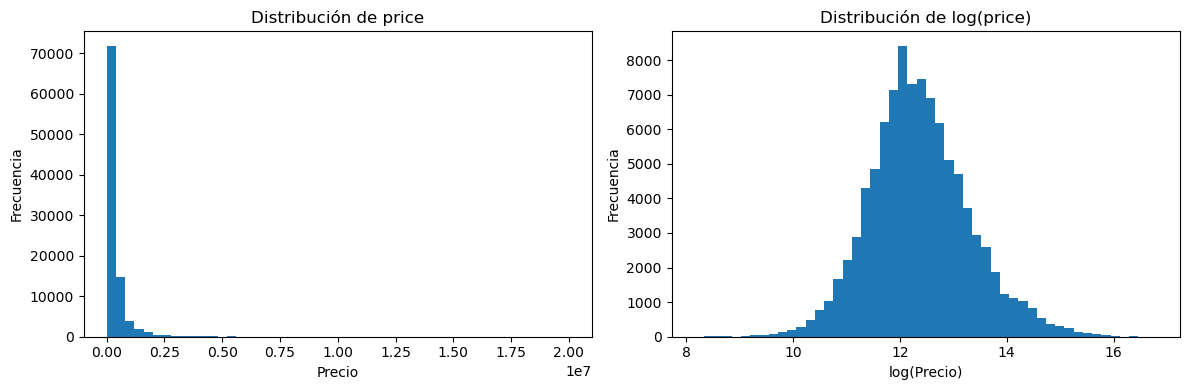

In [1300]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["price"], bins=50)
axes[0].set_title("Distribución de price")
axes[0].set_xlabel("Precio")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(np.log(df["price"]), bins=50)

axes[1].set_title("Distribución de log(price)")
axes[1].set_xlabel("log(Precio)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

In [1301]:
pd.DataFrame({
    "variable": ["price", "log_price"],
    "media": [
        df["price"].mean(),
        np.log(df["price"]).mean()
    ],
    "mediana": [
        df["price"].median(),
        np.log(df["price"]).median()
    ],
    "std": [
        df["price"].std(),
        np.log(df["price"]).std()
    ],
    "asimetría": [
        df["price"].skew(),
        np.log(df["price"]).skew()
    ]
})

,variable,media,mediana,std,asimetría
0,price,391016.820305,220000.000000,612940.359842,7.050535
1,log_price,12.369402,12.301383,0.941756,0.337970


In [1302]:
df["log_price"] = np.log(df["price"])

**Transformación de la variable objetivo `price`**

La variable `price` presenta una distribución fuertemente asimétrica hacia la derecha, con una asimetría de **7,05**. Además, la media (391.017 €) es considerablemente superior a la mediana (220.000 €), debido a la presencia de una cola derecha extensa y valores de precio muy elevados.

Para evaluar si una transformación logarítmica permite reducir esta asimetría, se compara la distribución original con la de `log(price)`. Tras la transformación, la asimetría se reduce hasta **0,34**, obteniéndose una distribución considerablemente más simétrica y concentrada.

Por este motivo, se decide utilizar **`log_price = log(price)` como variable objetivo durante el modelado**. Se mantiene `price` en el conjunto de datos para conservar la escala original en euros y facilitar posteriormente la interpretación y evaluación de las predicciones.

Inicialmente se había planteado evaluar `log1p(rpice)` como transformación logarítmica. Sin embargo, dado que `price` no tiene valores nulos ni negativos, se opta por usar directamente `log(price)`.

Esta transformación no implica que se descarte la información de `price`, sino que se modifica la escala utilizada por el modelo para reducir el efecto de los valores extremos y facilitar el aprendizaje de la relación entre las variables predictoras y el precio.



### 8.2. Comprobación de variables definitivas

In [1303]:
# Variables definitivas del dataset
pd.DataFrame({
    "variable": df.columns,
    "tipo": df.dtypes.astype(str).values,
    "n_unique": df.nunique().values,
    "n_missing": df.isna().sum().values
})

,variable,tipo,n_unique,n_missing
0,air_conditioner,int64,2,0
1,balcony,int64,2,0
2,bath_num,float64,26,0
3,built_in_wardrobe,int64,2,0
4,chimney,int64,2,0
5,condition,object,4,0
6,energetic_certif,object,4,0
7,garden,int64,2,0
8,house_id,int64,90455,0
9,house_type,object,18,0


In [1304]:
# Comprobación de duplicados
df.duplicated().sum()

5185

In [1305]:
# IDs distintos, registros totales
df["house_id"].nunique(), len(df)

(90455, 95701)

In [1306]:
df["house_id"].value_counts().value_counts().sort_index()

count
1    85209
2     5246
Name: count, dtype: int64

In [1307]:
# Vamos a ver si los house_id repetidos tienen el mismo precio
id_price = df.groupby("house_id")["price"].nunique()

pd.DataFrame({
    "house_id_repetidos": [(id_price > 1).sum()],
    "house_id_con_un_precio": [(id_price == 1).sum()],
    "house_id_con_varios_precios": [(id_price > 1).sum()]
})

,house_id_repetidos,house_id_con_un_precio,house_id_con_varios_precios
0,42,90413,42


In [1308]:
# Vemos si hay registros iguales sin tener en cuenta house_id

cols_sin_id = df.columns.drop("house_id")

duplicados_sin_id = df[df.duplicated(cols_sin_id, keep=False)]

pd.DataFrame({
    "registros_duplicados_sin_id": [len(duplicados_sin_id)]
})

,registros_duplicados_sin_id
0,12911


In [1309]:
# Vamos a ver si estos duplicados tienen el mismo precio

precio_por_grupo = (
    duplicados_sin_id
    .groupby(list(cols_sin_id))["price"]
    .nunique()
)

pd.DataFrame({
    "grupos_duplicados": [len(precio_por_grupo)],
    "grupos_un_precio": [(precio_por_grupo == 1).sum()],
    "grupos_varios_precios": [(precio_por_grupo > 1).sum()]
})

,grupos_duplicados,grupos_un_precio,grupos_varios_precios
0,6174,6174,0


**Decisión sobre `house_id`**

`house_id` se considera un identificador del inmueble y no una variable explicativa adecuada para el modelo, tal y como se había estudiado anteriormente. Aunque existen inmuebles que aparecen más de una vez, la gran mayoría de los identificadores son únicos y únicamente 42 identificadores presentan más de un precio asociado.

Además, al excluir `house_id` se identifican 12.911 registros pertenecientes a grupos duplicados. Estos registros presentan exactamente los mismos valores en el resto de variables y, en todos los casos, comparten el mismo precio. Por tanto, `house_id` actúa únicamente como identificador y no aporta información adicional para distinguir estos registros.

En consecuencia, se decide **eliminar `house_id` del conjunto de variables utilizadas por el modelo**. Los duplicados detectados tras su eliminación serán tratados como registros repetidos del mismo inmueble y se conservará un único registro por grupo.

In [1310]:
df = df.drop(columns="house_id")

In [1311]:
print(df.shape)
print(df.columns)

(95701, 21)
Index(['air_conditioner', 'balcony', 'bath_num', 'built_in_wardrobe',
       'chimney', 'condition', 'energetic_certif', 'garden', 'house_type',
       'lift', 'loc_zone', 'm2_real', 'price', 'reduced_mobility', 'room_num',
       'storage_room', 'swimming_pool', 'terrace', 'population_prov',
       'has_garage', 'log_price'],
      dtype='object')


In [1312]:
cols_duplicados = df.columns.drop("log_price")

duplicados = df[df.duplicated(cols_duplicados, keep=False)]

pd.DataFrame({
    "registros_duplicados": [len(duplicados)],
    "grupos_duplicados": [
        duplicados.groupby(list(cols_duplicados)).ngroups
    ]
})

,registros_duplicados,grupos_duplicados
0,12911,6174


In [1313]:
# Eliminamos los duplicados
df = df.drop_duplicates(subset=cols_duplicados, keep="first")

In [1314]:
pd.DataFrame({
    "registros_antes": [95701],
    "registros_despues": [len(df)],
    "registros_eliminados": [95701 - len(df)]
})

,registros_antes,registros_despues,registros_eliminados
0,95701,88964,6737


In [1315]:
df.duplicated().sum()

0

In [1316]:
df.shape

(88964, 21)

**Tratamiento de registros duplicados**

Una vez eliminado `house_id`, se vuelve a comprobar la existencia de registros duplicados utilizando el resto de variables del conjunto de datos. Para esta comprobación se excluye `log_price`, ya que es una transformación de `price` y, por tanto, no aporta información adicional para identificar registros repetidos.

Se identifican **12.911 registros pertenecientes a 6.174 grupos duplicados**. Esto significa que existen 6.174 combinaciones diferentes de características que aparecen repetidas en el conjunto de datos, acumulando un total de 12.911 registros. Algunos grupos aparecen más de dos veces.

Previamente se comprobó que todos estos grupos presentan un único valor de `price`, por lo que las observaciones repetidas no aportan información diferente para el modelado.

Por tanto, se consideran registros repetidos y se decide **conservar únicamente una observación de cada grupo**, eliminando las copias restantes.


### 8.3. Preparación para el modelado

Una vez finalizado el preprocesamiento, se realiza una última comprobación del conjunto de datos resultante. En este punto, el dataset cuenta con **88.964 registros y 21 variables**, sin valores ausentes ni registros duplicados.

Este conjunto de datos constituye la versión final del dataset tras el proceso de limpieza y transformación, y será la base utilizada posteriormente para el desarrollo de los modelos predictivos.

Finalmente, se guarda el dataset preprocesado en `data/processed/` para utilizarlo como entrada en el siguiente notebook, dedicado a la preparación de los datos para el modelado y al entrenamiento y evaluación de los distintos modelos.


In [1317]:
pd.DataFrame({
    "n_registros": [len(df)],
    "n_variables": [df.shape[1]],
    "valores_ausentes": [df.isna().sum().sum()],
    "registros_duplicados": [df.duplicated().sum()]
})

,n_registros,n_variables,valores_ausentes,registros_duplicados
0,88964,21,0,0


In [1318]:
processed_path = "../data/processed/spanish_houses_preprocessed_final.csv"
df.to_csv(processed_path, index=False)
print(f"Dataset preprocesado exportado en: {processed_path}")

Dataset preprocesado exportado en: ../data/processed/spanish_houses_preprocessed_final.csv


In [1319]:
df_check = pd.read_csv(processed_path)
print("Dimensiones del archivo exportado:", df_check.shape)

Dimensiones del archivo exportado: (88964, 21)
